# File 14 — Hybrid Image Branch App Inference Demo
Segmentation → CNN probability → handcrafted features → hybrid score → risk band.
Not a diagnosis. Research prototype only.


In [46]:
import json, os, shutil
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import cv2
import joblib
from PIL import Image
from scipy import ndimage
from scipy.stats import entropy as sp_entropy
from skimage.feature import graycomatrix, graycoprops
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision.models import efficientnet_b0
import segmentation_models_pytorch as smp

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
import cv2
import numpy as np


Device: cuda


## Configuration


In [47]:
# ====== PASTE YOUR IMAGE PATH HERE ======
IMAGE_PATH = r"WhatsApp Image 2026-05-13 at 9.31.59 PM.jpeg"
# =========================================

SEG_CKPT = Path(r'D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\05_training_runs\checkpoints\best_efficientnetb0_unet.pth')
CLS_CKPT = Path(r'D:\DIABETES\diabetes_pipeline_outputs\05_segmented_training_lighting_robust\best_segmented_lighting_robust_model.pth')
HYBRID_MODEL_PATH = Path(r'D:\DIABETES\diabetes_pipeline_outputs\11_hybrid_probability_fusion\11_hybrid_model.joblib')
SCALER_PATH = Path(r'D:\DIABETES\diabetes_pipeline_outputs\11_hybrid_probability_fusion\11_hybrid_scaler.joblib')
FEAT_COLS_PATH = Path(r'D:\DIABETES\diabetes_pipeline_outputs\10_hybrid_image_features\10_model_feature_columns.json')
HYBRID_SUMMARY_PATH = Path(r'D:\DIABETES\diabetes_pipeline_outputs\11_hybrid_probability_fusion\11_hybrid_best_model_summary.json')
OUTPUT_DIR = Path(r'D:\DIABETES\diabetes_pipeline_outputs\14_hybrid_app_inference_demo_outputs')

SEG_SIZE = 384; CLS_SIZE = 224; SEG_THRESHOLD = 0.5
MEAN = [0.485, 0.456, 0.406]; STD = [0.229, 0.224, 0.225]
MIN_TONGUE_PIXELS = 100
ERO_KERNEL = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))

with open(FEAT_COLS_PATH) as f:
    MODEL_FEATURES = json.load(f)

if HYBRID_SUMMARY_PATH.exists():
    with open(HYBRID_SUMMARY_PATH) as f:
        hybrid_sum = json.load(f)
    SELECTED_THRESHOLD = float(hybrid_sum.get('best_threshold', 0.45))
else:
    SELECTED_THRESHOLD = 0.45

print(f'Threshold: {SELECTED_THRESHOLD}')

# ── Debug: confirm path alignment with File 11 ──────────────────────────────
print()
print('=== FILE 14 CONSISTENCY CHECK ===')
print(f'CNN checkpoint (must match File 11): {CLS_CKPT}')
print(f'Hybrid model path: {HYBRID_MODEL_PATH}')
print(f'Scaler path: {SCALER_PATH}')
print(f'Feature columns path: {FEAT_COLS_PATH}')
print(f'CLAHE applied before CNN: NO (matches File 11 style)')
print(f'Selected threshold: {SELECTED_THRESHOLD}')
print('File 14 CNN probability is generated using the same checkpoint and preprocessing style as File 11 hybrid training.')
print('=================================')


Threshold: 0.3

=== FILE 14 CONSISTENCY CHECK ===
CNN checkpoint (must match File 11): D:\DIABETES\diabetes_pipeline_outputs\05_segmented_training_lighting_robust\best_segmented_lighting_robust_model.pth
Hybrid model path: D:\DIABETES\diabetes_pipeline_outputs\11_hybrid_probability_fusion\11_hybrid_model.joblib
Scaler path: D:\DIABETES\diabetes_pipeline_outputs\11_hybrid_probability_fusion\11_hybrid_scaler.joblib
Feature columns path: D:\DIABETES\diabetes_pipeline_outputs\10_hybrid_image_features\10_model_feature_columns.json
CLAHE applied before CNN: NO (matches File 11 style)
Selected threshold: 0.3
File 14 CNN probability is generated using the same checkpoint and preprocessing style as File 11 hybrid training.


## Load Models


In [48]:
# Segmentation
seg_model = smp.Unet(encoder_name='efficientnet-b0', encoder_weights=None, in_channels=3, classes=1, activation=None)
ckpt = torch.load(SEG_CKPT, map_location=DEVICE)
if isinstance(ckpt, dict) and 'model_state_dict' in ckpt: seg_model.load_state_dict(ckpt['model_state_dict'])
elif isinstance(ckpt, dict) and 'state_dict' in ckpt: seg_model.load_state_dict(ckpt['state_dict'])
else: seg_model.load_state_dict(ckpt)
seg_model = seg_model.to(DEVICE); seg_model.eval()

# Classifier
cls_model = efficientnet_b0(weights=None)
cls_model.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(cls_model.classifier[1].in_features, 1))
ckpt = torch.load(CLS_CKPT, map_location=DEVICE)
if isinstance(ckpt, dict) and 'model_state_dict' in ckpt: cls_model.load_state_dict(ckpt['model_state_dict'])
elif isinstance(ckpt, dict) and 'state_dict' in ckpt: cls_model.load_state_dict(ckpt['state_dict'])
else: cls_model.load_state_dict(ckpt)
cls_model = cls_model.to(DEVICE); cls_model.eval()

# Hybrid
hybrid_model = joblib.load(HYBRID_MODEL_PATH)
hybrid_scaler = joblib.load(SCALER_PATH)

print('All models loaded.')


All models loaded.


## Pipeline Functions


In [49]:
def correct_lighting_clahe(image_pil, clip_limit=1.5, tile_grid_size=(8, 8)):
    """Deterministic CLAHE lighting correction. Same as File 10/11 pipeline."""
    import numpy as np, cv2
    img_rgb = np.array(image_pil.convert('RGB'))
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_eq = clahe.apply(l)
    rgb_eq = cv2.cvtColor(cv2.merge([l_eq, a, b]), cv2.COLOR_LAB2RGB)
    return Image.fromarray(rgb_eq)

def pad_square(img):
    w, h = img.size; s = max(w, h)
    new = Image.new('RGB', (s, s), (0,0,0))
    new.paste(img, ((s-w)//2, (s-h)//2))
    return new

seg_transform = T.Compose([T.Lambda(pad_square), T.Resize((SEG_SIZE, SEG_SIZE)), T.ToTensor(), T.Normalize(mean=MEAN, std=STD)])
# Classifier preprocessing: CLAHE is applied before this transform (see cnn_predict).
cls_transform = T.Compose([T.Lambda(pad_square), T.Resize((CLS_SIZE, CLS_SIZE)), T.ToTensor(), T.Normalize(mean=MEAN, std=STD)])

def segment_tongue(img_pil):
    w, h = img_pil.size
    inp = seg_transform(img_pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = seg_model(inp)
    prob = torch.sigmoid(logits).cpu().numpy()[0, 0]
    mask = (prob > SEG_THRESHOLD).astype(np.uint8)
    mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)
    labeled, num = ndimage.label(mask)
    if num > 0:
        sizes = ndimage.sum(mask, labeled, range(1, num+1))
        mask = (labeled == np.argmax(sizes) + 1).astype(np.uint8)
    return mask

def create_crop_masked(img_rgb, mask):
    bb = img_rgb * mask[:,:,np.newaxis]
    rows = np.any(mask, axis=1); cols = np.any(mask, axis=0)
    if not rows.any(): return bb, (0, img_rgb.shape[0], 0, img_rgb.shape[1])
    y1,y2 = np.where(rows)[0][[0,-1]]; x1,x2 = np.where(cols)[0][[0,-1]]
    return bb[y1:y2+1, x1:x2+1].copy(), (int(y1),int(y2+1),int(x1),int(x2+1))

def cnn_predict(crop_masked_pil, debug_save_path=None):
    """Run CNN classifier on crop_masked PIL image.
    Preprocessing: CLAHE → pad_square → Resize(224) → ToTensor → Normalize.
    CLAHE matches File 11 lighting-robust CNN training pipeline.
    """
    crop_masked_pil = correct_lighting_clahe(crop_masked_pil)  # CLAHE before CNN — matches File 11
    inp = cls_transform(crop_masked_pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logit = cls_model(inp)
    prob = torch.sigmoid(logit).item()

    # Debug prints
    print(f'  [CNN DEBUG] Input tensor shape : {list(inp.shape)}')
    print(f'  [CNN DEBUG] Tensor min/max      : {inp.min().item():.4f} / {inp.max().item():.4f}')
    print(f'  [CNN DEBUG] Tensor mean/std     : {inp.mean().item():.4f} / {inp.std().item():.4f}')
    print(f'  [CNN DEBUG] Raw logit           : {logit.item():.6f}')
    print(f'  [CNN DEBUG] CNN probability     : {prob:.6f}')

    # Save classifier input image for inspection
    if debug_save_path is not None:
        from pathlib import Path
        import cv2, numpy as np
        Path(debug_save_path).parent.mkdir(parents=True, exist_ok=True)
        arr = np.array(crop_masked_pil)
        cv2.imwrite(str(debug_save_path), cv2.cvtColor(arr, cv2.COLOR_RGB2BGR))
        print(f'  [CNN DEBUG] Classifier input saved: {debug_save_path}')

    return prob

def color_ratio(hsv_px, h_lo, h_hi, s_lo, s_hi, v_lo, v_hi):
    h,s,v = hsv_px[:,0], hsv_px[:,1], hsv_px[:,2]
    return ((h>=h_lo)&(h<=h_hi)&(s>=s_lo)&(s<=s_hi)&(v>=v_lo)&(v<=v_hi)).sum()/max(len(h),1)

def extract_tongue_features(img_rgb, mask):
    # Apply CLAHE before feature extraction — matches File 10 pipeline
    img_pil_clahe = correct_lighting_clahe(Image.fromarray(img_rgb))
    img_rgb = np.array(img_pil_clahe)
    eroded = cv2.erode(mask, ERO_KERNEL, iterations=1)
    if eroded.sum() < MIN_TONGUE_PIXELS: eroded = mask
    tongue_px = img_rgb[mask==1]
    if len(tongue_px) < MIN_TONGUE_PIXELS: return None
    feat = {}
    for i,ch in enumerate(['r','g','b']):
        feat[f'rgb_mean_{ch}'] = float(tongue_px[:,i].mean())
        feat[f'rgb_std_{ch}'] = float(tongue_px[:,i].std())
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    hsv_px = hsv[mask==1]
    for i,ch in enumerate(['h','s','v']):
        feat[f'hsv_mean_{ch}'] = float(hsv_px[:,i].mean())
        feat[f'hsv_std_{ch}'] = float(hsv_px[:,i].std())
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    lab_px = lab[mask==1]
    for i,ch in enumerate(['l','a','b']):
        feat[f'lab_mean_{ch}'] = float(lab_px[:,i].mean())
        feat[f'lab_std_{ch}'] = float(lab_px[:,i].std())
    feat['pink_red_ratio'] = color_ratio(hsv_px,0,15,30,255,50,255) + color_ratio(hsv_px,160,180,30,255,50,255)
    feat['white_coating_ratio'] = color_ratio(hsv_px,0,180,0,40,160,255)
    feat['yellow_ratio'] = color_ratio(hsv_px,15,35,30,255,100,255)
    feat['dark_tongue_pixel_ratio'] = float((hsv_px[:,2]<60).mean())
    feat['bright_tongue_pixel_ratio'] = float((hsv_px[:,2]>220).mean())
    feat['saturation_mean'] = float(hsv_px[:,1].mean())
    feat['saturation_std'] = float(hsv_px[:,1].std())
    feat['value_mean'] = float(hsv_px[:,2].mean())
    feat['value_std'] = float(hsv_px[:,2].std())
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    inner_px = gray[eroded==1]
    feat['laplacian_variance_inner'] = float(cv2.Laplacian(gray.astype(np.float64),cv2.CV_64F).var())
    hist,_ = np.histogram(inner_px,bins=64,range=(0,256),density=True)
    feat['entropy_inner'] = float(sp_entropy(hist+1e-12))
    iy,ix = np.where(eroded==1)
    patch = gray[iy.min():iy.max()+1, ix.min():ix.max()+1]
    patch_q = (patch//4).astype(np.uint8)
    try:
        glcm = graycomatrix(patch_q, [1], [0], 64, symmetric=True, normed=True)
        feat['glcm_contrast_inner'] = float(graycoprops(glcm,'contrast')[0,0])
        feat['glcm_homogeneity_inner'] = float(graycoprops(glcm,'homogeneity')[0,0])
        feat['glcm_energy_inner'] = float(graycoprops(glcm,'energy')[0,0])
        feat['glcm_correlation_inner'] = float(graycoprops(glcm,'correlation')[0,0])
    except:
        for k in ['glcm_contrast_inner','glcm_homogeneity_inner','glcm_energy_inner','glcm_correlation_inner']:
            feat[k] = 0.0
    return feat

def compute_qc(mask, img_shape):
    h,w = img_shape[:2]; fg = mask.sum()
    qc = {'mask_fg_ratio': fg/(h*w), 'failed_no_mask': fg==0}
    if fg > 0:
        rows=np.any(mask,axis=1); cols=np.any(mask,axis=0)
        y1,y2=np.where(rows)[0][[0,-1]]; x1,x2=np.where(cols)[0][[0,-1]]
        ec = sum([y1==0, y2==h-1, x1==0, x2==w-1])
        qc['edge_touch'] = ec >= 3
        qc['large_mask'] = qc['mask_fg_ratio'] > 0.85
        qc['small_mask'] = qc['mask_fg_ratio'] < 0.02
        qc['tiny_bbox'] = ((x2-x1+1)*(y2-y1+1))/(h*w) < 0.02
    else:
        qc['edge_touch']=qc['large_mask']=False; qc['small_mask']=qc['tiny_bbox']=True
    return qc

def get_risk_band(prob, threshold):
    if prob < 0.20: return 'Low image-based risk'
    elif prob < threshold: return 'Borderline / uncertain'
    elif prob < 0.70: return 'Elevated image-based risk'
    else: return 'High image-based risk'

def assess_retake(qc):
    if qc['failed_no_mask'] or qc['small_mask'] or qc['tiny_bbox']:
        return True, False, 'Please retake with tongue centered and fully visible.'
    if qc['large_mask']:
        return False, True, 'Prediction generated, but review recommended (large mask).'
    if qc.get('edge_touch', False):
        return False, False, 'Prediction generated. Segmentation touched edges; review recommended.'
    return False, False, 'Image accepted.'

print('Pipeline functions defined.')


Pipeline functions defined.


## Run Full Inference


In [50]:
def run_hybrid_inference(image_path, save=True):
    img_pil = Image.open(image_path).convert('RGB')
    img_rgb = np.array(img_pil)
    mask = segment_tongue(img_pil)
    crop_masked, bbox = create_crop_masked(img_rgb, mask)
    qc = compute_qc(mask, img_rgb.shape)
    retake_req, retake_rec, message = assess_retake(qc)

    if retake_req:
        result = {'image_path':str(image_path), 'cnn_probability':None, 'hybrid_probability':None,
                  'predicted_class':None, 'risk_band':None, 'threshold':SELECTED_THRESHOLD,
                  'retake_required':True, 'retake_recommended':False, 'message':message, **qc}
        return result, {'original':img_rgb,'mask':mask,'crop_masked':crop_masked}

    cm_pil = Image.fromarray(crop_masked)
    ts_debug = datetime.now().strftime('%Y%m%d_%H%M%S')
    debug_img_path = OUTPUT_DIR / f'{Path(str(image_path)).stem}_{ts_debug}' / 'classifier_input_debug.png'
    print()
    print('=== CNN INFERENCE DEBUG ===')
    print(f'  CNN checkpoint: {CLS_CKPT}')
    print(f'  Preprocessing: CLAHE → pad_square → Resize(224) → ToTensor → Normalize')
    print(f'  CLAHE before CNN: YES')
    print(f'  CLAHE before feature extraction: YES')
    print(f'  Classifier input save path: {debug_img_path}')
    cnn_prob = cnn_predict(cm_pil, debug_save_path=debug_img_path)
    print(f'  CNN probability (final): {cnn_prob:.6f}')
    print('===========================')
    tongue_feats = extract_tongue_features(img_rgb, mask)
    if tongue_feats is None:
        result = {'image_path':str(image_path), 'cnn_probability':cnn_prob, 'hybrid_probability':None,
                  'predicted_class':None, 'risk_band':None, 'threshold':SELECTED_THRESHOLD,
                  'retake_required':True, 'retake_recommended':False,
                  'message':'Feature extraction failed. Please retake.', **qc}
        return result, {'original':img_rgb,'mask':mask,'crop_masked':crop_masked}

    hybrid_input = [cnn_prob] + [tongue_feats.get(f, 0.0) for f in MODEL_FEATURES]
    hybrid_input_s = hybrid_scaler.transform([hybrid_input])
    hybrid_prob = float(hybrid_model.predict_proba(hybrid_input_s)[0, 1])
    pred_class = 'diabetes' if hybrid_prob >= SELECTED_THRESHOLD else 'non_diabetes'
    risk_band = get_risk_band(hybrid_prob, SELECTED_THRESHOLD)

    result = {
        'image_path': str(image_path),
        'cnn_probability': round(cnn_prob, 6),
        'hybrid_probability': round(hybrid_prob, 6),
        'predicted_class': pred_class,
        'risk_band': risk_band,
        'threshold': SELECTED_THRESHOLD,
        'retake_required': retake_req,
        'retake_recommended': retake_rec,
        'message': message,
        **qc,
    }

    if save:
        ts = datetime.now().strftime('%Y%m%d_%H%M%S')
        run_dir = OUTPUT_DIR / f'{Path(image_path).stem}_{ts}'
        run_dir.mkdir(parents=True, exist_ok=True)
        shutil.copy2(image_path, run_dir / f'original{Path(image_path).suffix}')
        cv2.imwrite(str(run_dir/'mask.png'), mask*255)
        cv2.imwrite(str(run_dir/'crop_masked.png'), cv2.cvtColor(crop_masked, cv2.COLOR_RGB2BGR))
        with open(run_dir/'result_summary.json','w') as f: json.dump(result, f, indent=2, default=str)
        with open(run_dir/'result_summary.txt','w') as f:
            for k,v in result.items(): f.write(f'{k}: {v}\n')

    return result, {'original':img_rgb,'mask':mask,'crop_masked':crop_masked}

result, images = run_hybrid_inference(IMAGE_PATH)



=== CNN INFERENCE DEBUG ===
  CNN checkpoint: D:\DIABETES\diabetes_pipeline_outputs\05_segmented_training_lighting_robust\best_segmented_lighting_robust_model.pth
  Preprocessing: CLAHE → pad_square → Resize(224) → ToTensor → Normalize
  CLAHE before CNN: YES
  CLAHE before feature extraction: YES
  Classifier input save path: D:\DIABETES\diabetes_pipeline_outputs\14_hybrid_app_inference_demo_outputs\WhatsApp Image 2026-05-13 at 9.31.59 PM_20260513_093748\classifier_input_debug.png
  [CNN DEBUG] Input tensor shape : [1, 3, 224, 224]
  [CNN DEBUG] Tensor min/max      : -2.1179 / 2.3960
  [CNN DEBUG] Tensor mean/std     : -0.8643 / 1.3594
  [CNN DEBUG] Raw logit           : -1.332053
  [CNN DEBUG] CNN probability     : 0.208820
  [CNN DEBUG] Classifier input saved: D:\DIABETES\diabetes_pipeline_outputs\14_hybrid_app_inference_demo_outputs\WhatsApp Image 2026-05-13 at 9.31.59 PM_20260513_093748\classifier_input_debug.png
  CNN probability (final): 0.208820


## Display Results


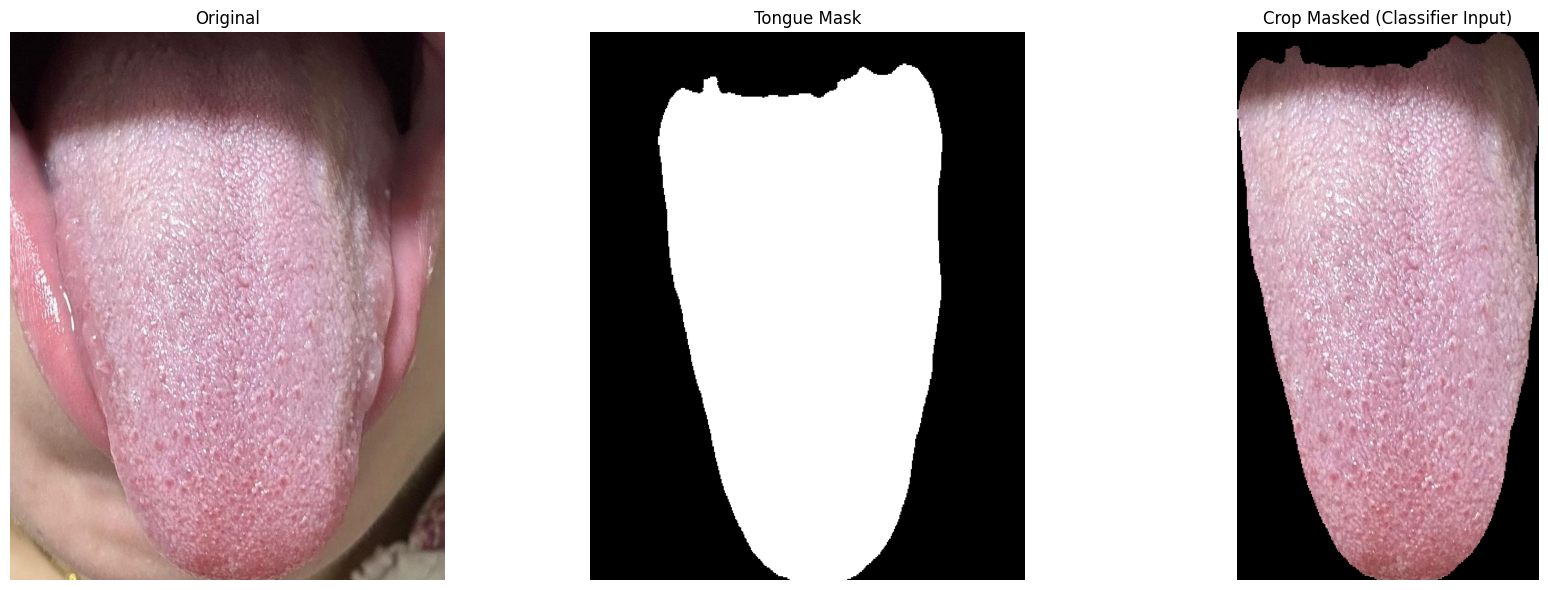

HYBRID IMAGE BRANCH RESULT
  image_path: WhatsApp Image 2026-05-13 at 9.31.59 PM.jpeg
  cnn_probability: 0.20882
  hybrid_probability: 0.295666
  predicted_class: non_diabetes
  risk_band: Borderline / uncertain
  threshold: 0.3
  retake_required: False
  retake_recommended: False
  message: Image accepted.
  mask_fg_ratio: 0.47722497522299306
  failed_no_mask: False
  edge_touch: False
  large_mask: False
  small_mask: False
  tiny_bbox: False

>>> Image accepted.
>>> CNN probability: 0.2088
>>> Hybrid probability: 0.2957
>>> Risk band: Borderline / uncertain
>>> Predicted class: non_diabetes

DISCLAIMER: This is NOT a diagnosis.
This is an image-based screening/risk-estimation research prototype.
Always consult a physician.


In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(images['original']); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(images['mask'], cmap='gray'); axes[1].set_title('Tongue Mask'); axes[1].axis('off')
axes[2].imshow(images['crop_masked']); axes[2].set_title('Crop Masked (Classifier Input)'); axes[2].axis('off')
plt.tight_layout(); plt.show()

print('='*60)
print('HYBRID IMAGE BRANCH RESULT')
print('='*60)
for k,v in result.items():
    print(f'  {k}: {v}')
print('='*60)
print(f'\n>>> {result["message"]}')
if result.get('hybrid_probability') is not None:
    print(f'>>> CNN probability: {result["cnn_probability"]:.4f}')
    print(f'>>> Hybrid probability: {result["hybrid_probability"]:.4f}')
    print(f'>>> Risk band: {result["risk_band"]}')
    print(f'>>> Predicted class: {result["predicted_class"]}')
else:
    print('>>> Prediction not generated.')
print()
print('DISCLAIMER: This is NOT a diagnosis.')
print('This is an image-based screening/risk-estimation research prototype.')
print('Always consult a physician.')
